## Table of Contents

1. Loading the dataset
2. Data Pre-processing
3. Rule 1 - Extracting the sentences with President's mention
4. Rule 2 - Extracting the mentions of initiatives
5. Rule 3 - Relation Extraction part 1
6. Rule 4 - Relation Extraction part 2
7. Combining Rule 3 and Rule 4
8. Rule 5: Patterns using Preposition

## 2. Data Pre-processing

In [4]:
# importing libraries
import glob
import pandas as pd
import re

In [5]:
# names of all the folders in the dataset
folders = glob.glob('UNGDC_1970-2018/Converted sessions/Session*')

In [6]:
# list of folders
folders

['UNGDC_1970-2018/Converted sessions\\Session 25 - 1970',
 'UNGDC_1970-2018/Converted sessions\\Session 26 - 1971',
 'UNGDC_1970-2018/Converted sessions\\Session 27 - 1972',
 'UNGDC_1970-2018/Converted sessions\\Session 28 - 1973',
 'UNGDC_1970-2018/Converted sessions\\Session 29 - 1974',
 'UNGDC_1970-2018/Converted sessions\\Session 30 - 1975',
 'UNGDC_1970-2018/Converted sessions\\Session 31 - 1976',
 'UNGDC_1970-2018/Converted sessions\\Session 32 - 1977',
 'UNGDC_1970-2018/Converted sessions\\Session 33 - 1978',
 'UNGDC_1970-2018/Converted sessions\\Session 34 - 1979',
 'UNGDC_1970-2018/Converted sessions\\Session 35 - 1980',
 'UNGDC_1970-2018/Converted sessions\\Session 36 - 1981',
 'UNGDC_1970-2018/Converted sessions\\Session 37 - 1982',
 'UNGDC_1970-2018/Converted sessions\\Session 38 - 1983',
 'UNGDC_1970-2018/Converted sessions\\Session 39 - 1984',
 'UNGDC_1970-2018/Converted sessions\\Session 40 - 1985',
 'UNGDC_1970-2018/Converted sessions\\Session 41 - 1986',
 'UNGDC_1970-2

In [7]:
# creating a Dataframe to store the speeches
df = pd.DataFrame(columns=['Country','Speech','Session','Year'])

In [8]:
# read speeches by USA
i = 0
# for each folder
for file in folders:
    # getting the txt file containing speech of USA
    speech = glob.glob(file+'/USA*.txt')
    # reading the txt file
    with open(speech[0],encoding='utf8') as f:
        # reading the speech
        df.loc[i,'Speech'] = f.read()
        # extracting the year of speech
        df.loc[i,'Year'] = speech[0].split('_')[-1].split('.')[0]
        # extracting the session
        df.loc[i,'Session'] = speech[0].split('_')[-2]
        # storing the country name
        df.loc[i,'Country'] = speech[0].split('_')[0].split("/")[-1]
        # Increment counter
        i += 1

In [10]:
# first 5 rows of the created dataset
df.head()

,Country,Speech,Session,Year
0,UNGDC,1.\t It is my privilege to extend to you once ...,25,1970
1,UNGDC,"Mr. President, I should like first of all to ...",26,1971
2,UNGDC,During the past few years the world has made r...,27,1972
3,UNGDC,﻿35.\tI should like to add my congratulations ...,28,1973
4,UNGDC,"Last year, at the previous session [.2124th me...",29,1974


In [11]:
# sample speech from the dataset
df['Speech'][2]

'During the past few years the world has made remarkable advances toward the Charter goal of practicing tolerance and living together in peace with one another as good neighbors.\n45.\tIn 1972 alone, the United States and the Soviet Union have undertaken with each other to do their utmost to avoid military confrontations, to respect the sovereign equality of all countries and to promote conditions in which no country would be subject to outside interference in its internal affairs. The Soviet Union and the United States have also placed precise limitations on our defensive and, at least for the next five years, on our offensive strategic missile systems. The United States and the People\'s Republic of China have undertaken to broaden the understanding between our peoples, to improve relations between us in the conviction that this would be in the interests of all States, and to oppose any efforts to establish hegemony in Asia or toward division of the world into spheres of influence. T

In [12]:
# function to preprocess speech
def clean(text):
    # removing paragraph numbers
    text = re.sub('[0-9]+.\t','',str(text))
    # removing new line characters
    text = re.sub('\n ','',str(text))
    text = re.sub('\n',' ',str(text))
    # removing apostrophes
    text = re.sub("'s",'',str(text))
    # removing hyphens
    text = re.sub("-",' ',str(text))
    text = re.sub("— ",'',str(text))
    # removing quotation marks
    text = re.sub('\"','',str(text))
    # removing salutations
    text = re.sub("Mr\.",'Mr',str(text))
    text = re.sub("Mrs\.",'Mrs',str(text))
    # removing any reference to outside text
    text = re.sub("[\(\[].*?[\)\]]", "", str(text))

    return text

In [13]:
# preprocessing speeches
df['Speech_clean'] = df['Speech'].apply(clean)

In [14]:
# first 5 rows of the dataset
df.head()

,Country,Speech,Session,Year,Speech_clean
0,UNGDC,1.\t It is my privilege to extend to you once ...,25,1970,It is my privilege to extend to you once agai...
1,UNGDC,"Mr. President, I should like first of all to ...",26,1971,"Mr President, I should like first of all to a..."
2,UNGDC,During the past few years the world has made r...,27,1972,During the past few years the world has made r...
3,UNGDC,﻿35.\tI should like to add my congratulations ...,28,1973,﻿I should like to add my congratulations to th...
4,UNGDC,"Last year, at the previous session [.2124th me...",29,1974,"Last year, at the previous session , in my fir..."


In [15]:
# sample cleaned speech
df['Speech_clean'][1]

" Mr President, I should like first of all to associate myself with the previous speakers who have congratulated you on your election to the high office of President of the twenty sixth session of the General Assembly. The United States is confident that you will pursue the ideals of the Charter with the same dedication as your distinguished predecessors.  The United Nations is an important instrument of peace. It is also the repository of many of the world hopes. We must ensure that it is true to those hopes; that we here assembled the representatives of 130 nations  meet our high responsibilities not only to our own world but to the world of the future. Building a structure of peace a structure that will stand requires patience, dedication and realism. Working at peace working at it seriously means more than long hours of careful deliberation. It means putting aside preconceptions; it means weighing carefully what our real interests are, not only as citizens of our own countries, but

In [16]:
# splitting sentences
def sentences(text):
    # split sentences and questions
    text = re.split('[.?]', text)
    clean_sent = []
    for sent in text:
        clean_sent.append(sent)
    return clean_sent

In [17]:
# creating a new column to store the sentences
df['Sentence'] = df['Speech_clean'].apply(sentences)

In [18]:
# first 5 rows
df.head()

,Country,Speech,Session,Year,Speech_clean,Sentence
0,UNGDC,1.\t It is my privilege to extend to you once ...,25,1970,It is my privilege to extend to you once agai...,[ It is my privilege to extend to you once aga...
1,UNGDC,"Mr. President, I should like first of all to ...",26,1971,"Mr President, I should like first of all to a...","[ Mr President, I should like first of all to ..."
2,UNGDC,During the past few years the world has made r...,27,1972,During the past few years the world has made r...,[During the past few years the world has made ...
3,UNGDC,﻿35.\tI should like to add my congratulations ...,28,1973,﻿I should like to add my congratulations to th...,[﻿I should like to add my congratulations to t...
4,UNGDC,"Last year, at the previous session [.2124th me...",29,1974,"Last year, at the previous session , in my fir...","[Last year, at the previous session , in my fi..."


In [19]:
# sample sentence list from the dataset
df['Sentence'][1]

[' Mr President, I should like first of all to associate myself with the previous speakers who have congratulated you on your election to the high office of President of the twenty sixth session of the General Assembly',
 ' The United States is confident that you will pursue the ideals of the Charter with the same dedication as your distinguished predecessors',
 '  The United Nations is an important instrument of peace',
 ' It is also the repository of many of the world hopes',
 ' We must ensure that it is true to those hopes; that we here assembled the representatives of 130 nations  meet our high responsibilities not only to our own world but to the world of the future',
 ' Building a structure of peace a structure that will stand requires patience, dedication and realism',
 ' Working at peace working at it seriously means more than long hours of careful deliberation',
 ' It means putting aside preconceptions; it means weighing carefully what our real interests are, not only as citiz

In [20]:
# create a dataframe containing sentences
df2 = pd.DataFrame(columns=['Sentence','Year','Len'])

row_list = []

# for each speech
for i in range(len(df)):
    # for each sentence
    for sent in df.loc[i,'Sentence']:

        # calculating the word count in a sentence
        wordcount = len(sent.split())
        # extracting the year of speech
        year = df.loc[i,'Year']

        dict1 = {'Year':year,'Sentence':sent,'Len':wordcount}
        row_list.append(dict1)

df2 = pd.DataFrame(row_list)

In [21]:
# first 5 rows
df2.head()

,Year,Sentence,Len
0,1970,It is my privilege to extend to you once agai...,33
1,1970,Your country has few peers in the contributio...,17
2,1970,Your father was a leader in the League of Nat...,29
3,1970,In the United Nations community we have long ...,65
4,1970,We are indeed fortunate to have you to lead u...,23


In [22]:
# shape of the dataset
df2.shape

(8948, 3)

Sample sentences from dataset:

1.  For that reason, **President Reagan**, in his speech to this body last year, proposed that the United States and the Soviet Union exchange visits of experts at test sites to measure directly the yields of nuclear weapon test
2.  **President Reagan** has directed our scientists and engineers to examine, in the light of new technologies and fully in accord with the Anti Ballistic Missile Treaty   the feasibility of defense against ballistic missile attack
3.   **President Reagan** approach to foreign policy is  grounded squarely on standards drawn from the  pragmatic American experience
4.  Let me start by joining the **President of Brazil** in conveying to the people and Government of Mexico our deep sympathy over the devastation wrought by earthquakes and our solidarity with them as they work to recover and rebuild

## 3. Rule 1 - Extracting the sentences with President's mention

In [23]:
# importing spacy and its matcher function
import spacy
from spacy.matcher import Matcher

# load english language model
nlp = spacy.load('en_core_web_sm',disable=['ner','textcat'])

In [24]:
# function to find sentences mentioning president
def find_names(text):

    names = []

    # spacy doc
    doc = nlp(text)

    # pattern
    pattern = [{'LOWER':'president'},
              {'POS':'ADP','OP':'?'},
              {'POS':'PROPN'}]

    # Matcher class object
    matcher = Matcher(nlp.vocab)
    matcher.add("names",[pattern])

    matches = matcher(doc)

    # finding patterns in the text
    for i in range(0,len(matches)):

        # match: id, start, end
        token = doc[matches[i][1]:matches[i][2]]
        # append token to list
        names.append(str(token))

    return names

In [25]:
# extracting sentences with president's mentions
extracted_sentences = []
for i in range(df2.shape[0]):
    extracted_sentences.append(find_names(df2['Sentence'][i]))

# storing the extracted sentences in the dataframe
df2['President_Names'] = extracted_sentences

In [26]:
# first 5 rows
df2.head()

,Year,Sentence,Len,President_Names
0,1970,It is my privilege to extend to you once agai...,33,[]
1,1970,Your country has few peers in the contributio...,17,[]
2,1970,Your father was a leader in the League of Nat...,29,[]
3,1970,In the United Nations community we have long ...,65,[]
4,1970,We are indeed fortunate to have you to lead u...,23,[]


In [27]:
# extracting only the non-null outputs
mention = []
for i in range(df2.shape[0]):
    if df2['President_Names'][i] != []:
        mention.append(df2['President_Names'][i])

mention

[['President Nixon'],
 ['President Nasser'],
 ['President Nixon'],
 ['President Nixon'],
 ['President Nixon'],
 ['President Nixon'],
 ['President Nixon'],
 ['President Nixon'],
 ['President Nixon'],
 ['President Nixon'],
 ['President Nixon'],
 ['President Nixon'],
 ['President Nixon'],
 ['President Nixon'],
 ['President of Mexico'],
 ['President Ford'],
 ['President Ford'],
 ['President Ford'],
 ['President Ford'],
 ['President Ford'],
 ['President Ford'],
 ['President of Lebanon'],
 ['President Ford'],
 ['President Carter'],
 ['President Carter'],
 ['President Carter'],
 ['President Carter'],
 ['President Mondaleat'],
 ['President Carter', 'President in January'],
 ['President Carter'],
 ['President Carter'],
 ['President Reagan'],
 ['President Reagan'],
 ['President Reagan'],
 ['President Reagan'],
 ['President Reagan'],
 ['President Reagan'],
 ['President Reagan'],
 ['President Reagan'],
 ['President Reagan'],
 ['President Dwight'],
 ['President of Brazil'],
 ['President Sarney'],
 

In [28]:
# extracting only those sentences which has president's mention
sentences_president = []
for i in range(df2.shape[0]):
    if df2['President_Names'][i] != []:
        sentences_president.append(df2['Sentence'][i])

sentences_president

[' As President Nixon said in this Assembly a year ago: ',
 ' While recent developments in the area, including the tragic death of President Nasser, have cast a shadow over the high hopes of just a few weeks ago that a beginning toward that goal had been made, those hopes have not been extinguished',
 ' As President Nixon pointed out in this forum a year ago, this issue involves the interests of',
 " President Nixon, in a series of policy decisions and especially in his recent announcement on the new focus of United States economic assistance, has made clear our intention: \tTo reverse the downward trend in United States development assistance; \tTo increase substantially United States contributions to multilateral development institutions including the World Bank, the International Development Association, the regional development banks and the United Nations Development program so that, as the capabilities of these institutions increase, we may be able to channel through them most of

In [29]:
# number of sentences containing president's mention
len(sentences_president)

107

In [30]:
# sample sentences with president's mention
sentences_president[1]

' While recent developments in the area, including the tragic death of President Nasser, have cast a shadow over the high hopes of just a few weeks ago that a beginning toward that goal had been made, those hopes have not been extinguished'

In [31]:
# sample sentences with president's mention
sentences_president[10]

' President Nixon has also pledged a major effort to assist both VietNamese States in post war reconstruction'

Sample sentences from dataset:
1. The United States will continue its strong efforts to advance **the United Nations plan** for Namibia
2. The United States and Italy have proposed **a Global Peace Operations Initiative**
3. For 35 years, **the North Atlantic alliance** has guaranteed the peace in Europe

## 4. Rule 2 - Extracting the mentions of initiatives

In [34]:
# to check if keyswords like 'programs','schemes', etc. are present in sentences

def prog_sent(text):

    patterns = [r'(?i)\bplan\b',
               r'(?i)\bprogramme\b',
               r'(?i)\bscheme\b',
               r'(?i)\bcampaign\b',
               r'(?i)\binitiative\b',
               r'(?i)\bconference\b',
               r'(?i)\bagreement\b',
               r'(?i)\balliance\b']

    output = []
    flag = 0
    for pat in patterns:
        if re.search(pat, text) != None:
            flag = 1
            break
    return flag

# apply function
df2['Check_Schemes'] = df2['Sentence'].apply(prog_sent)

In [35]:
# first 5 rows
df2.head()

,Year,Sentence,Len,President_Names,Check_Schemes
0,1970,It is my privilege to extend to you once agai...,33,[],0
1,1970,Your country has few peers in the contributio...,17,[],0
2,1970,Your father was a leader in the League of Nat...,29,[],0
3,1970,In the United Nations community we have long ...,65,[],0
4,1970,We are indeed fortunate to have you to lead u...,23,[],0


In [36]:
# to extract initiatives using pattern matching
def all_schemes(text,check):

    schemes = []

    doc = nlp(text)

    # initiatives
    prog_list = ['programme','scheme',
                 'initiative','campaign',
                 'agreement','conference',
                 'alliance','plan']

    # pattern to match initiatives names
    pattern = [{'POS':'DET'},
               {'POS':'PROPN','DEP':'compound'},
               {'POS':'PROPN','DEP':'compound'},
               {'POS':'PROPN','OP':'?'},
               {'POS':'PROPN','OP':'?'},
               {'POS':'PROPN','OP':'?'},
               {'LOWER':{'IN':prog_list},'OP':'+'}
              ]

    if check == 0:
        # return blank list
        return schemes

    # Matcher class object
    matcher = Matcher(nlp.vocab)
    matcher.add("matching", [pattern])
    matches = matcher(doc)

    for i in range(0,len(matches)):

        # match: id, start, end
        start, end = matches[i][1], matches[i][2]

        if doc[start].pos_=='DET':
            start = start+1

        # matched string
        span = str(doc[start:end])

        if (len(schemes)!=0) and (schemes[-1] in span):
            schemes[-1] = span
        else:
            schemes.append(span)

    return schemes

# apply function
df2['Schemes1'] = df2.apply(lambda x:all_schemes(x.Sentence,x.Check_Schemes),axis=1)

In [37]:
# first 5 rows
df2.head()

,Year,Sentence,Len,President_Names,Check_Schemes,Schemes1
0,1970,It is my privilege to extend to you once agai...,33,[],0,[]
1,1970,Your country has few peers in the contributio...,17,[],0,[]
2,1970,Your father was a leader in the League of Nat...,29,[],0,[]
3,1970,In the United Nations community we have long ...,65,[],0,[]
4,1970,We are indeed fortunate to have you to lead u...,23,[],0,[]


In [38]:
df2.shape

(8948, 6)

In [39]:
# extracting only the non-null outputs
mention = []
for i in range(df2.shape[0]):
    if df2['Schemes1'][i] != []:
        mention.append(df2['Schemes1'][i])

mention

[['United States initiative'],
 ['United Nations Conference'],
 ['Suez Canal agreement'],
 ['World Food Conference'],
 ['World Population Conference', 'World Food Conference'],
 ['Third United Nations Conference'],
 ['Geneva Peace Conference'],
 ['Geneva Peace Conference'],
 ['Bonn Economic Summit Conference'],
 ['Bonn Economic Summit Conference'],
 ['World Food Conference'],
 ['World Food Conference'],
 ['United Nations Conference'],
 ['Second Review Conference'],
 ['United Nations Conference'],
 ['World Bank programme'],
 ['United Nations plan'],
 ['United Nations plan'],
 ['multi fibre agreement'],
 ['Caribbean Basin Initiative'],
 ['North Atlantic alliance'],
 ['San Francisco Conference'],
 ['Third Review Conference'],
 ['North American Free Trade Agreement'],
 ['San Francisco Conference'],
 ['North American Free Trade Agreement'],
 ['North American Free Trade Agreement'],
 ['United Nations Conference'],
 ['United Nations International Drug Control Programme'],
 ['Good Friday Agree

In [40]:
# extracting sentences which mentions some initiatives
initiatives = []
for i in range(df2.shape[0]):
    if df2['Schemes1'][i] != []:
        initiatives.append(df2['Sentence'][i])

initiatives

[' Security Council resolution 242  stands as a beacon pointing the way to peace, and the parties concerned, in accepting the United States initiative of June, have committed themselves to carry out that resolution in all its parts',
 ' Already the plans for the United Nations Conference on the Human Environment in 1972 have begun to take shape and have helped to focus the attention of United Nations Member Governments on this worldwide challenge; but we should not wait for the Stockholm Conference before launching necessary initiatives',
 ' A fair approach should be founded on two basic principles:  That a Suez Canal agreement is merely a step towards complete and full implementation of resolution 242  within a reasonable period of time, and not an end in itself that has to be clearly established in any agreement; also  That neither side can realistically expect \\to achieve, as part of an interim agreement, complete agreement on the terms and conditions of an over all settlement  if 

In [41]:
# number of sentences which mentions some initiatives
len(initiatives)

40

In [42]:
# sample sentences containing initiatives
initiatives[0]

' Security Council resolution 242  stands as a beacon pointing the way to peace, and the parties concerned, in accepting the United States initiative of June, have committed themselves to carry out that resolution in all its parts'

In [43]:
# sample sentences containing initiatives
initiatives[3]

' The United States is prepared to join with all nations at the World Food Conference in Rome to launch the truly massive effort which is required'

## 5. Rule 3 - Relation Extraction part 1

Sample sentences from dataset:
1.   The United **States** will **support** these **principles**
2.    Yet these very small **entities need** more than most the **assistance** that the United Nations system can provide
3.  I have proposed to Congress that the United **States provide** additional **funding** for our work in Iraq, the greatest financial commitment of its kind since the Marshall Plan

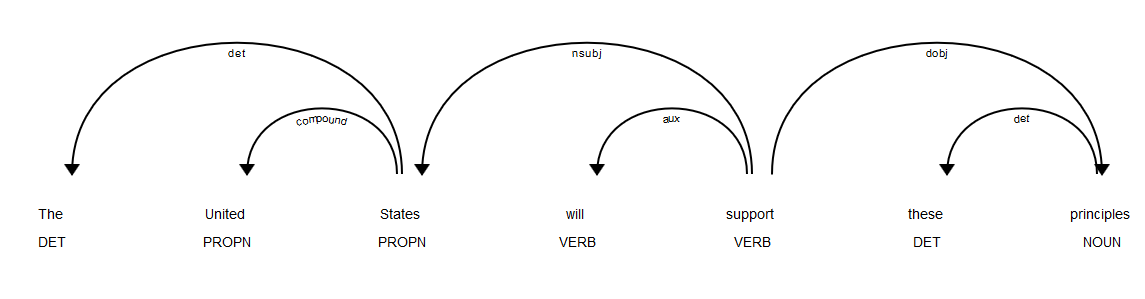

In [44]:
# function for rule 3: noun(subject), verb, noun(object)
def rule3(text):

    doc = nlp(text)

    sent = []

    for token in doc:

        # if the token is a verb
        if (token.pos_=='VERB'):

            phrase =''

            # only extract noun or pronoun subjects
            for sub_tok in token.lefts:

                if (sub_tok.dep_ in ['nsubj','nsubjpass']) and (sub_tok.pos_ in ['NOUN','PROPN','PRON']):

                    # add subject to the phrase
                    phrase += sub_tok.text

                    # save the root of the verb in phrase
                    phrase += ' '+token.lemma_

                    # check for noun or pronoun direct objects
                    for sub_tok in token.rights:

                        # save the object in the phrase
                        if (sub_tok.dep_ in ['dobj']) and (sub_tok.pos_ in ['NOUN','PROPN']):

                            phrase += ' '+sub_tok.text
                            sent.append(phrase)

    return sent

In [ ]:
# create a df containing sentence and its output for rule 3
row_list = []

for i in range(len(df2)):

    sent = df2.loc[i,'Sentence']
    year = df2.loc[i,'Year']
    output = rule3(sent)
    dict1 = {'Year':year,'Sentence':sent,'Output':output}
    row_list.append(dict1)

df_rule3 = pd.DataFrame(row_list)

In [ ]:
# first 5 rows
df_rule3.head()

,Year,Sentence,Output
0,2012,﻿I would like to begin today by telling the As...,[]
1,2012,"Chris was born in a town called Grass Valley,...",[]
2,2012,"As a young man, Chris joined the Peace Corps ...",[Chris join Corps]
3,2012,He would carry that commitment throughout his...,[He carry commitment]
4,2012,"As a diplomat, he worked from Egypt to Syria,...",[]


In [ ]:
# selecting non-empty output rows
df_show = pd.DataFrame(columns=df_rule3.columns)

for row in range(len(df_rule3)):

    if len(df_rule3.loc[row,'Output'])!=0:
        df_show = df_show.append(df_rule3.loc[row,:])

# reset the index
df_show.reset_index(inplace=True, drop=True)

Streaming output truncated to the last 5000 lines.
<ipython-input-55-cbdd7781f2a5>:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_show = df_show.append(df_rule3.loc[row,:])
<ipython-input-55-cbdd7781f2a5>:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_show = df_show.append(df_rule3.loc[row,:])
<ipython-input-55-cbdd7781f2a5>:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_show = df_show.append(df_rule3.loc[row,:])
<ipython-input-55-cbdd7781f2a5>:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_show = df_show.append(df_rule3.loc[row,:])
<ipython-input-55-cbdd7781f2a5>:7: FutureWarning: The frame.append method is deprecat

In [ ]:
df_show.head()

,Year,Sentence,Output
0,2012,"As a young man, Chris joined the Peace Corps ...",[Chris join Corps]
1,2012,He would carry that commitment throughout his...,[He carry commitment]
2,2012,"As America’s representative, he helped the Li...",[he help people]
3,2012,"After the revolution, he supported the birth ...","[he support birth, Libyans hold elections]"
4,2012,Chris Stevens loved his work,[Stevens love work]


In [ ]:
# number of outputs
df_show.shape

(4021, 3)

In [ ]:
# separate subject, verb and object

verb_dict = dict()
dis_dict = dict()
dis_list = []

# iterating over all the sentences
for i in range(len(df_show)):

    # sentence containing the output
    sentence = df_show.loc[i,'Sentence']
    # year of the sentence
    year = df_show.loc[i,'Year']
    # output of the sentence
    output = df_show.loc[i,'Output']

    # iterating over all the outputs from the sentence
    for sent in output:

        # separate subject, verb and object
        n1, v, n2 = sent.split()[:1], sent.split()[1], sent.split()[2:]

        # append to list, along with the sentence
        dis_dict = {'Sentence':sentence,'Year':year,'Noun1':n1,'Verb':v,'Noun2':n2}
        dis_list.append(dis_dict)

        # counting the number of sentences containing the verb
        verb = sent.split()[1]
        if verb in verb_dict:
            verb_dict[verb]+=1
        else:
            verb_dict[verb]=1

df_sep = pd.DataFrame(dis_list)

In [ ]:
# first 5 rows
df_sep.head()

,Sentence,Year,Noun1,Verb,Noun2
0,"As a young man, Chris joined the Peace Corps ...",2012,[Chris],join,[Corps]
1,He would carry that commitment throughout his...,2012,[He],carry,[commitment]
2,"As America’s representative, he helped the Li...",2012,[he],help,[people]
3,"After the revolution, he supported the birth ...",2012,[he],support,[birth]
4,"After the revolution, he supported the birth ...",2012,[Libyans],hold,[elections]


In [ ]:
# top 10 verbs
df_sep['Verb'].value_counts()[:10]

have       351
take       162
make       139
support     99
give        92
see         80
seek        59
provide     57
face        57
build       52
Name: Verb, dtype: int64

In [ ]:
# selecting a verb and looking at its patterns
df_sep[df_sep['Verb']=='support'].head(15)

,Sentence,Year,Noun1,Verb,Noun2
3,"After the revolution, he supported the birth ...",2012,[he],support,[birth]
18,"Since then, the world has been captivated by ...",2012,[States],support,[forces]
21,"We supported change in Egypt, because our sup...",2012,[We],support,[change]
45,We do not do so because we support hateful sp...,2012,[we],support,[speech]
174,The United States strongly supports his leade...,1997,[States],support,[leadership]
222,We will support the consolidation of market d...,1993,[We],support,[consolidation]
271,But the reason we have supported such mission...,1993,[we],support,[missions]
278,We support the creation of a genuine United N...,1993,[We],support,[creation]
314,Those names include a man who supported his w...,2001,[who],support,[wife]
438,The United States strongly supports the basic...,1979,[States],support,[elements]


## 6. Rule 4: Relation Extraction part 2

Sample sentences from the dataset:
1.  With support from **many countries**, we have made **impressive progress**
2.  Because of their **unique expertise** and regional legitimacy, they can be instruments for solving some of the **hardest challenges** we face
3.  We are right to aim high and take on the **mightiest tasks**

In [ ]:
from spacy import displacy
displacy.render(nlp("With support from many countries, we have made impressive progress"), style='dep',jupyter=True)

In [ ]:
# function for rule 4
def rule4(text):

    doc = nlp(text)

    pat = []

    # iterate over tokens
    for token in doc:
        phrase = ''
        # if the word is a subject noun or an object noun
        if (token.pos_ == 'NOUN')\
            and (token.dep_ in ['dobj','pobj','nsubj','nsubjpass']):

            # iterate over the children nodes
            for subtoken in token.children:
                # if word is an adjective or has a compound dependency
                if (subtoken.pos_ == 'ADJ') or (subtoken.dep_ == 'compound'):
                    phrase += subtoken.text + ' '

            if len(phrase)!=0:
                phrase += token.text

        if  len(phrase)!=0:
            pat.append(phrase)


    return pat

In [ ]:
# create a df containing sentence and its output for rule 4
row_list = []

for i in range(len(df2)):

    sent = df2.loc[i,'Sentence']
    year = df2.loc[i,'Year']
    # rule
    output = rule4(sent)

    dict1 = {'Year':year,'Sentence':sent,'Output':output}
    row_list.append(dict1)

df_rule4 = pd.DataFrame(row_list)

In [ ]:
# first 5 rows
df_rule4.head()

,Year,Sentence,Output
0,2012,﻿I would like to begin today by telling the As...,[]
1,2012,"Chris was born in a town called Grass Valley,...",[]
2,2012,"As a young man, Chris joined the Peace Corps ...",[young man]
3,2012,He would carry that commitment throughout his...,[]
4,2012,"As a diplomat, he worked from Egypt to Syria,...",[]


In [ ]:
# selecting non-empty outputs
df_show = pd.DataFrame(columns=df_rule4.columns)

for row in range(len(df_rule4)):

    if len(df_rule4.loc[row,'Output'])!=0:
        df_show = df_show.append(df_rule4.loc[row,:])

# reset the index
df_show.reset_index(inplace=True, drop=True)

Streaming output truncated to the last 5000 lines.
<ipython-input-66-467b66dfd267>:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_show = df_show.append(df_rule4.loc[row,:])
<ipython-input-66-467b66dfd267>:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_show = df_show.append(df_rule4.loc[row,:])
<ipython-input-66-467b66dfd267>:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_show = df_show.append(df_rule4.loc[row,:])
<ipython-input-66-467b66dfd267>:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_show = df_show.append(df_rule4.loc[row,:])
<ipython-input-66-467b66dfd267>:7: FutureWarning: The frame.append method is deprecat

In [ ]:
# number of matches
df_show.shape

(6218, 3)

In [ ]:
# first 15 rows
df_show.head(15)

,Year,Sentence,Output
0,2012,"As a young man, Chris joined the Peace Corps ...",[young man]
1,2012,He was known for walking the streets of the c...,"[local food, many people, broad smile]"
2,2012,"Chris went to Benghazi, arriving on a cargo s...","[cargo ship, early days, Libyan revolution]"
3,2012,"As America’s representative, he helped the Li...","[Libyan people, violent conflict]"
4,2012,"After the revolution, he supported the birth ...","[new democracy, new institutions]"
5,2012,"Two weeks ago, he travelled to Benghazi to re...",[new cultural center]
6,2012,"Like his fellow Foreign Service officers, he ...","[fellow Service officers, international cooper..."
7,2012,"He acted with humility, but he also stood up ...",[own destiny]
8,2012,The attacks on the American civilians in Beng...,[American civilians]
9,2012,We are grateful for the assistance we receive...,[Libyan people]


### 7. Combining Rule 3 and Rule 4

Sample sentences:
1.  With support from many countries, **we** have **made impressive progress**
2. **It** will **require military planners** the world over to recognize that training for peace operations is a legitimate part of every nation security strategy

In [ ]:
# modifying rule 4
def rule4_mod(text,index):

    doc = nlp(text)

    phrase = ''

    # iterate over tokens
    for token in doc:

        if token.i == index:

            # iterate over the children nodes
            for subtoken in token.children:
                # if word is an adjective
                if (subtoken.pos_ == 'ADJ') or (subtoken.dep_ == 'compound'):
                    phrase += ' '+subtoken.text
            break

    return phrase

In [ ]:
# using rule 3 and rule 4
def rule3_mod(text):

    doc = nlp(text)

    sent = []

    for token in doc:
        # root word
        if (token.pos_=='VERB'):

            phrase =''

            # only extract noun or pronoun subjects
            for sub_tok in token.lefts:

                if (sub_tok.dep_ in ['nsubj','nsubjpass']) and (sub_tok.pos_ in ['NOUN','PROPN','PRON']):

                    # look for subject modifier
                    adj = rule4_mod(text,sub_tok.i)

                    phrase += adj + ' ' + sub_tok.text

                    # save the root word of the word
                    phrase += ' '+token.lemma_

                    # check for noun or pronoun direct objects
                    for sub_tok in token.rights:

                        if (sub_tok.dep_ in ['dobj']) and (sub_tok.pos_ in ['NOUN','PROPN']):

                            # look for object modifier
                            adj = rule4_mod(text,sub_tok.i)

                            phrase += adj+' '+sub_tok.text
                            sent.append(phrase)

    return sent

In [ ]:
# create a df containing sentence and its output for modified rule
row_list = []

for i in range(len(df2)):

    sent = df2.loc[i,'Sentence']
    year = df2.loc[i,'Year']
    output = rule3_mod(sent)
    dict1 = {'Year':year,'Sentence':sent,'Output':output}
    row_list.append(dict1)

df_rule = pd.DataFrame(row_list)

In [ ]:
# first 5 rows
df_rule.head()

,Year,Sentence,Output
0,2012,﻿I would like to begin today by telling the As...,[]
1,2012,"Chris was born in a town called Grass Valley,...",[]
2,2012,"As a young man, Chris joined the Peace Corps ...",[ Chris join Peace Corps]
3,2012,He would carry that commitment throughout his...,[ He carry commitment]
4,2012,"As a diplomat, he worked from Egypt to Syria,...",[]


In [ ]:
# selecting non-empty outputs
df_show_mod = pd.DataFrame(columns=df_rule.columns)

for row in range(len(df_rule)):

    if len(df_rule.loc[row,'Output'])!=0:
        df_show_mod = df_show_mod.append(df_rule.loc[row,:])

# reset the index
df_show_mod.reset_index(inplace=True, drop=True)

Streaming output truncated to the last 5000 lines.
<ipython-input-73-8971d3ad55d1>:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_show_mod = df_show_mod.append(df_rule.loc[row,:])
<ipython-input-73-8971d3ad55d1>:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_show_mod = df_show_mod.append(df_rule.loc[row,:])
<ipython-input-73-8971d3ad55d1>:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_show_mod = df_show_mod.append(df_rule.loc[row,:])
<ipython-input-73-8971d3ad55d1>:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_show_mod = df_show_mod.append(df_rule.loc[row,:])
<ipython-input-73-8971d3ad55d1>:7: FutureWarning: The fra

In [ ]:
# number of matches
df_show_mod.shape

(4021, 3)

In [ ]:
# first 15 rows
df_show_mod.head(20)

,Year,Sentence,Output
0,2012,"As a young man, Chris joined the Peace Corps ...",[ Chris join Peace Corps]
1,2012,He would carry that commitment throughout his...,[ He carry commitment]
2,2012,"As America’s representative, he helped the Li...",[ he help Libyan people]
3,2012,"After the revolution, he supported the birth ...","[ he support birth, Libyans hold elections]"
4,2012,Chris Stevens loved his work,[ Chris Stevens love work]
5,2012,"He took pride in the country he served, and h...","[ He take pride, he see dignity]"
6,2012,I tell this story because Chris Stevens embod...,[ I tell story]
7,2012,"Like his fellow Foreign Service officers, he ...",[ he build bridges]
8,2012,"I also appreciate that, in recent days, the l...",[ leaders take steps]
9,2012,They are also an assault on the very ideals ...,"[ United Nations found notion, people resolve..."


In [ ]:
# Sample sentence
print(df_show_mod.loc[4,'Output'])
print(df_show_mod.loc[4,'Sentence'])

[' Chris Stevens love work']
 Chris Stevens loved his work


In [ ]:
# Sample sentence
print(df_show_mod.loc[17,'Output'])
print(df_show_mod.loc[17,'Sentence'])

[' We take positions']
 We have taken those positions because we believe that freedom and self determination are not unique to one culture


## 8. Rule 5: Patterns using Preposition

Sample sentences:
1.  We all believe the **benefits of globalization** must be allocated more broadly within and among societies
2. As the Millennium Summit reflected, we have no **shortage of** worthy **goals**
3. It should preserve the special **responsibility for peacekeeping** of the Security Council permanent members

In [ ]:


# Sample sentence
from spacy import displacy
displacy.render(nlp('''We all believe the benefits of globalization must
be allocated more broadly within and among societies'''),
                style='dep',jupyter=True)

In [ ]:
# rule 5 function
def rule5(text):

    doc = nlp(text)

    sent = []

    for token in doc:

        # look for prepositions
        if token.pos_=='ADP':

            phrase = ''

            # if its head word is a noun
            if token.head.pos_=='NOUN':

                # append noun and preposition to phrase
                phrase += token.head.text
                phrase += ' '+token.text

                # check the nodes to the right of the preposition
                for right_tok in token.rights:
                    # append if it is a noun or proper noun
                    if (right_tok.pos_ in ['NOUN','PROPN']):
                        phrase += ' '+right_tok.text

                if len(phrase)>2:
                    sent.append(phrase)

    return sent

In [ ]:
# create a df containing sentence and its output for rule 5
row_list = []

for i in range(len(df2)):

    sent = df2.loc[i,'Sentence']
    year = df2.loc[i,'Year']

    # rule
    output = rule5(sent)

    dict1 = {'Year':year,'Sentence':sent,'Output':output}
    row_list.append(dict1)

df_rule = pd.DataFrame(row_list)

In [ ]:
# first 5 rows
df_rule.head()

,Year,Sentence,Output
0,2012,﻿I would like to begin today by telling the As...,[]
1,2012,"Chris was born in a town called Grass Valley,...",[son of lawyer]
2,2012,"As a young man, Chris joined the Peace Corps ...",[people of Africa]
3,2012,He would carry that commitment throughout his...,[]
4,2012,"As a diplomat, he worked from Egypt to Syria,...",[]


In [ ]:
# select non-empty outputs
df_show = pd.DataFrame(columns=df_rule.columns)

for row in range(len(df_rule)):

    if len(df_rule.loc[row,'Output'])!=0:
        df_show = df_show.append(df_rule.loc[row,:])

# reset the index
df_show.reset_index(inplace = True, drop = True)

Streaming output truncated to the last 5000 lines.
<ipython-input-82-7ef47fd4b84f>:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_show = df_show.append(df_rule.loc[row,:])
<ipython-input-82-7ef47fd4b84f>:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_show = df_show.append(df_rule.loc[row,:])
<ipython-input-82-7ef47fd4b84f>:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_show = df_show.append(df_rule.loc[row,:])
<ipython-input-82-7ef47fd4b84f>:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_show = df_show.append(df_rule.loc[row,:])
<ipython-input-82-7ef47fd4b84f>:7: FutureWarning: The frame.append method is deprecated a

In [ ]:
# first 5 rows
df_show.head()

,Year,Sentence,Output
0,2012,"Chris was born in a town called Grass Valley,...",[son of lawyer]
1,2012,"As a young man, Chris joined the Peace Corps ...",[people of Africa]
2,2012,He was known for walking the streets of the c...,[streets of cities]
3,2012,"Chris went to Benghazi, arriving on a cargo s...",[days of revolution]
4,2012,"As America’s representative, he helped the Li...","[vision for future, rights of Libyans]"


In [ ]:
# separate noun, preposition and noun

prep_dict = dict()
dis_dict = dict()
dis_list = []

# iterating over all the sentences
for i in range(len(df_show)):

    # sentence containing the output
    sentence = df_show.loc[i,'Sentence']
    # year of the sentence
    year = df_show.loc[i,'Year']
    # output of the sentence
    output = df_show.loc[i,'Output']

    # iterating over all the outputs from the sentence
    for sent in output:

        # separate subject, verb and object
        n1, p, n2 = sent.split()[0], sent.split()[1], sent.split()[2:]

        # append to list, along with the sentence
        dis_dict = {'Sentence':sentence,'Year':year,'Noun1':n1,'Preposition':p,'Noun2':n2}
        dis_list.append(dis_dict)

        # counting the number of sentences containing the verb
        prep = sent.split()[1]
        if prep in prep_dict:
            prep_dict[prep]+=1
        else:
            prep_dict[prep]=1

df_sep= pd.DataFrame(dis_list)

In [ ]:
# first 10 rows
df_sep.head(10)

,Sentence,Year,Noun1,Preposition,Noun2
0,"Chris was born in a town called Grass Valley,...",2012,son,of,[lawyer]
1,"As a young man, Chris joined the Peace Corps ...",2012,people,of,[Africa]
2,He was known for walking the streets of the c...,2012,streets,of,[cities]
3,"Chris went to Benghazi, arriving on a cargo s...",2012,days,of,[revolution]
4,"As America’s representative, he helped the Li...",2012,vision,for,[future]
5,"As America’s representative, he helped the Li...",2012,rights,of,[Libyans]
6,"After the revolution, he supported the birth ...",2012,birth,of,[democracy]
7,"After the revolution, he supported the birth ...",2012,decades,of,[dictatorship]
8,"Like his fellow Foreign Service officers, he ...",2012,bridges,across,[oceans]
9,"He acted with humility, but he also stood up ...",2012,set,of,[principles]


In [ ]:
# top 10 prepositions
df_sep['Preposition'].value_counts()[:10]

of         6110
in         1211
for         887
to          567
on          343
with        250
between     202
from        139
as          120
against     117
Name: Preposition, dtype: int64

In [ ]:
# selecting a preposition and looking at its patterns
df_sep[df_sep['Preposition'] == 'against'].head(10)

,Sentence,Year,Noun1,Preposition,Noun2
69,"Like me, the majority of Americans are Christ...",2012,blasphemy,against,[beliefs]
74,"We do so because, given the power of faith in...",2012,weapon,against,[speech]
124,Let us condemn incitement against Sufi Muslim...,2012,incitement,against,[pilgrims]
269,Two years ago I called upon all the members o...,1997,fight,against,[forces]
286,To punish those responsible for crimes agains...,1997,crimes,against,[humanity]
492,We will also reform our own system of export ...,1993,battle,against,[proliferation]
596,We will defend ourselves and our future again...,2001,future,against,[terror]
636,Not every nation will be part of every action...,2001,action,against,[enemy]
643,Some nations want to play their part in the f...,2001,fight,against,[terror]
648,We are making progress against military targe...,2001,progress,against,[targets]
